In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
opr_df=pd.read_csv("/Volumes/DATA/logist/data/raw/operations_complete.csv")

In [6]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [7]:
#inspect dataset
opr_df.shape
opr_df.head()
opr_df.info()
opr_df.describe()

(5475, 35)

,date,warehouse_id,shift_id,month,weekday,base_volume,monthly_multiplier,weekday_multiplier,shift_share,expected_volume,...,units_procced,utilization_factor,error_rate,errors,errors_percet,backlog_factor,on_time_rate,on_time_ships,late_shipments,on_time_ships_percet
0,2025-01-01,WH01,S1,1,2,4200,0.85,1.0,0.40,1428,...,23504,1.0,0.008406,99,0.84,1.0,0.963949,11328,424,96.39
1,2025-01-01,WH01,S2,1,2,4200,0.85,1.0,0.35,1250,...,10112,1.0,0.007361,74,0.73,1.0,0.942965,9535,577,94.30
2,2025-01-01,WH01,S3,1,2,4200,0.85,1.0,0.25,892,...,14976,1.0,0.009199,69,0.92,1.0,0.949632,7111,377,94.96
3,2025-01-01,WH02,S1,1,2,5000,0.85,1.0,0.40,1700,...,28096,1.0,0.007633,107,0.76,1.0,0.971524,13648,400,97.15
4,2025-01-01,WH02,S2,1,2,5000,0.85,1.0,0.35,1488,...,10936,1.0,0.009456,103,0.94,1.0,0.957892,10476,460,95.79


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           5475 non-null   object 
 1   warehouse_id                   5475 non-null   object 
 2   shift_id                       5475 non-null   object 
 3   month                          5475 non-null   int64  
 4   weekday                        5475 non-null   int64  
 5   base_volume                    5475 non-null   int64  
 6   monthly_multiplier             5475 non-null   float64
 7   weekday_multiplier             5475 non-null   float64
 8   shift_share                    5475 non-null   float64
 9   expected_volume                5475 non-null   int64  
 10  volume                         5475 non-null   int64  
 11  shipments                      5475 non-null   int64  
 12  base_workers                   5475 non-null   i

,month,weekday,base_volume,monthly_multiplier,weekday_multiplier,shift_share,expected_volume,volume,shipments,base_workers,...,units_procced,utilization_factor,error_rate,errors,errors_percet,backlog_factor,on_time_rate,on_time_ships,late_shipments,on_time_ships_percet
count,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,...,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000,5475.000000
mean,6.526027,2.997260,3900.000000,1.005342,0.914521,0.333333,1195.338813,1195.891872,9567.134977,23.200000,...,14667.451324,1.111562,0.008884,86.905023,0.888446,0.991722,0.952238,9073.290228,493.844749,95.223784
std,3.448166,1.998125,675.339398,0.188028,0.202828,0.062367,474.807647,491.071567,3928.572536,4.166914,...,9359.982453,0.179400,0.001942,46.631479,0.194223,0.023877,0.024952,3606.448990,463.822678,2.495232
min,1.000000,0.000000,3000.000000,0.800000,0.550000,0.250000,330.000000,239.000000,1912.000000,18.000000,...,1912.000000,1.000000,0.003204,12.000000,0.320000,0.920000,0.850614,1843.000000,40.000000,85.060000
25%,4.000000,1.000000,3500.000000,0.900000,0.650000,0.250000,838.000000,827.000000,6616.000000,20.000000,...,8172.000000,1.000000,0.007515,54.000000,0.750000,1.000000,0.950586,6350.000000,248.000000,95.060000
50%,7.000000,3.000000,3800.000000,1.000000,1.000000,0.350000,1134.000000,1124.000000,8992.000000,23.000000,...,11912.000000,1.000000,0.008544,77.000000,0.850000,1.000000,0.958618,8599.000000,357.000000,95.860000
75%,10.000000,5.000000,4200.000000,1.050000,1.050000,0.400000,1470.000000,1481.000000,11848.000000,25.000000,...,18648.000000,1.400000,0.009946,108.500000,0.990000,1.000000,0.965751,11204.500000,518.000000,96.580000
max,12.000000,6.000000,5000.000000,1.500000,1.100000,0.400000,3300.000000,3770.000000,30160.000000,30.000000,...,80688.000000,1.400000,0.017328,404.000000,1.740000,1.000000,0.990000,27062.000000,3580.000000,99.000000


In [84]:
#missing values
opr_df.isnull().sum()

#duplicates
opr_df.duplicated().sum()

#imp.cols

opr_df[["date","warehouse_id","shift_id","workers","labor_hours","shipments",'Productivity',
       'capacity','utilization_perct', 'backlog','errors', 'errors_percet',"on_time_ships_percet"]].head()

date                             0
warehouse_id                     0
shift_id                         0
month                            0
weekday                          0
base_volume                      0
monthly_multiplier               0
weekday_multiplier               0
shift_share                      0
expected_volume                  0
volume                           0
shipments                        0
base_workers                     0
shift_worker_multiplier          0
workers                          0
labor_hours                      0
Productivity                     0
base_productivity                0
shift_productivity_multiplier    0
expected_productivity            0
capacity                         0
productivity                     0
utilization                      0
utilization_perct                0
backlog                          0
units_procced                    0
utilization_factor               0
error_rate                       0
errors              

0

,date,warehouse_id,shift_id,workers,labor_hours,shipments,Productivity,capacity,utilization_perct,backlog,errors,errors_percet,on_time_ships_percet
0,2025-01-01,WH01,S1,25,200,11752,7.345000,17850,65.84,0,99,0.84,96.39
1,2025-01-01,WH01,S2,24,192,10112,6.583333,16320,61.96,0,74,0.73,94.30
2,2025-01-01,WH01,S3,19,152,7488,6.157895,10982,68.18,0,69,0.92,94.96
3,2025-01-01,WH02,S1,30,240,14048,7.316667,22680,61.94,0,107,0.76,97.15
4,2025-01-01,WH02,S2,28,224,10936,6.102679,20160,54.25,0,103,0.94,95.79


In [80]:
final=["date","warehouse_id","shift_id","workers","labor_hours","shipments","units_procced",'Productivity','is_peak',
       'capacity','utilization_perct', 'backlog','errors', 'errors_percet',"on_time_ships_percet","late_shipments","on_time_ships"]

In [81]:
df=opr_df[final].copy()
df.head()

KeyError: "['is_peak'] not in index"

In [11]:
df["date"]=pd.to_datetime(df["date"])

# monthly analysis
# weekday analysis
#weekly analysys
# date filtering

In [86]:
df["year"]=(df["date"].dt.year)
df["month"]=(df["date"].dt.month)
df["month_nm"]=(df["date"].dt.month_name())
df["day_of_week"]=(df["date"].dt.day_name())
df["is_weekend"]=(df["date"].dt.weekday>5)
df["is_peak"] = (df["utilization_perct"] > 85)
df.head()

,date,warehouse_id,shift_id,workers,labor_hours,shipments,units_procced,Productivity,capacity,utilization_perct,...,on_time_ships,year,month,month_nm,day_of_week,is_weekend,utilization_band,is_peak,backlog_rate_pct,high_pressure
0,2025-01-01,WH01,S1,25,200,11752,23504,7.345000,17850,65.84,...,11328,2025,1,January,Wednesday,False,Normal,False,0.0,False
1,2025-01-01,WH01,S2,24,192,10112,10112,6.583333,16320,61.96,...,9535,2025,1,January,Wednesday,False,Normal,False,0.0,False
2,2025-01-01,WH01,S3,19,152,7488,14976,6.157895,10982,68.18,...,7111,2025,1,January,Wednesday,False,Normal,False,0.0,False
3,2025-01-01,WH02,S1,30,240,14048,28096,7.316667,22680,61.94,...,13648,2025,1,January,Wednesday,False,Normal,False,0.0,False
4,2025-01-01,WH02,S2,28,224,10936,10936,6.102679,20160,54.25,...,10476,2025,1,January,Wednesday,False,Low,False,0.0,False


In [87]:
df.to_csv("/Volumes/DATA/logist/data/processed/cleaned_oper.csv", index=False)


**which warehouse processes the most shipments?**

In [14]:
warehouse_volume=df.groupby("warehouse_id")["shipments"].sum().sort_values(ascending=False) #most shipments by top2

**which warehouse processes the highest avg productivity?**

In [15]:
warehouse_productivity=df.groupby("warehouse_id")["Productivity"].mean().sort_values(ascending=False).round(2)#highest productivity  w02 despite inc in shipments

**which warehouse processes the highest avg utilization?**

In [16]:
warehouse_utilization=df.groupby("warehouse_id")["utilization_perct"].mean().sort_values(ascending=False).round(2)#top 2 are highly utilised their capacity

**which warehouse processes the highest backlog?**

In [17]:
warehouse_backlog=df.groupby("warehouse_id")["backlog"].sum().sort_values(ascending=False)

* w03 higest productivty, utilization and backlog too

*to analyse is w03 backlog caused by insufficient capacuty despite high productivity*

<AxesSubplot:title={'center':'Total Shipments by Warehouse'}, xlabel='warehouse_id'>

Text(0.5, 0, 'Warehouse')

Text(0, 0.5, 'Total Shipments')

<AxesSubplot:title={'center':'Average Productivity by Warehouse'}, xlabel='warehouse_id'>

Text(0.5, 0, 'Warehouse')

...

Text(0.5, 0, 'Warehouse')

Text(0, 0.5, 'Utilization (%)')

<AxesSubplot:title={'center':'Total Backlog by Warehouse'}, xlabel='warehouse_id'>

Text(0.5, 0, 'Warehouse')

Text(0, 0.5, 'Total Backlog')

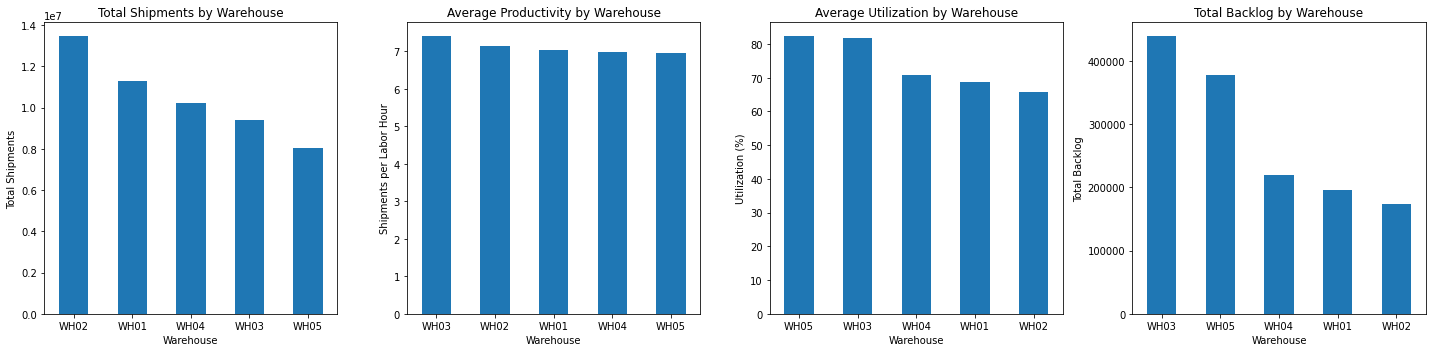

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Total Shipments
warehouse_volume.plot(
    kind="bar",
    ax=axes[0],
    title="Total Shipments by Warehouse"
)
axes[0].set_xlabel("Warehouse")
axes[0].set_ylabel("Total Shipments")
axes[0].tick_params(axis="x", rotation=0)

# 2. Productivity
warehouse_productivity.plot(
    kind="bar",
    ax=axes[1],
    title="Average Productivity by Warehouse"
)
axes[1].set_xlabel("Warehouse")
axes[1].set_ylabel("Shipments per Labor Hour")
axes[1].tick_params(axis="x", rotation=0)

# 3. Utilization
warehouse_utilization.plot(
    kind="bar",
    ax=axes[2],
    title="Average Utilization by Warehouse"
)
axes[2].set_xlabel("Warehouse")
axes[2].set_ylabel("Utilization (%)")
axes[2].tick_params(axis="x", rotation=0)

# 4. Backlog
warehouse_backlog.plot(
    kind="bar",
    ax=axes[3],
    title="Total Backlog by Warehouse"
)
axes[3].set_xlabel("Warehouse")
axes[3].set_ylabel("Total Backlog")
axes[3].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


Observation:

WH03 has the highest backlog.why?

investigate relation btw high utilization and high backlog.

In [19]:
warehouse_summary = (
    df.groupby("warehouse_id").agg(
        total_shipments=("shipments", "sum"),
        avg_productivity=("Productivity", "mean"),
        avg_utilization=("utilization_perct", "mean"),
        total_backlog=("backlog", "sum"),
        total_errors=("errors", "sum"),
        avg_on_time_delivery=("on_time_ships_percet", "mean")
    )
    .round(2)
)
warehouse_summary

,total_shipments,avg_productivity,avg_utilization,total_backlog,total_errors,avg_on_time_delivery
warehouse_id,,,,,,
WH01,11274144,7.04,68.62,196564,98741,95.54
WH02,13458032,7.14,65.85,173104,116794,95.56
WH03,9411536,7.40,81.89,439460,91001,94.78
WH04,10200656,6.99,70.78,219093,90266,95.41
WH05,8035696,6.96,82.31,378520,79003,94.84


In [20]:
warehouse_summary.sort_values("total_backlog", ascending=False)

,total_shipments,avg_productivity,avg_utilization,total_backlog,total_errors,avg_on_time_delivery
warehouse_id,,,,,,
WH03,9411536,7.40,81.89,439460,91001,94.78
WH05,8035696,6.96,82.31,378520,79003,94.84
WH04,10200656,6.99,70.78,219093,90266,95.41
WH01,11274144,7.04,68.62,196564,98741,95.54
WH02,13458032,7.14,65.85,173104,116794,95.56


In [21]:
correlation = warehouse_summary[
    [
        "avg_utilization",
        "total_backlog"
    ]
].corr()

correlation

,avg_utilization,total_backlog
avg_utilization,1.000000,0.975912
total_backlog,0.975912,1.000000


* The corr shows a positive relationship between utilization and backlog
* analysis at the shift/day level is required as the data is less (only 5 warehouses)

In [22]:
correlation_shift = df[
    [
        "utilization_perct",
        "backlog"
    ]
].corr()

correlation_shift

,utilization_perct,backlog
utilization_perct,1.000000,0.655329
backlog,0.655329,1.000000


<Figure size 576x360 with 0 Axes>

Text(0.5, 1.0, 'Warehouse Utilization vs Backlog')

Text(0.5, 0, 'Utilization (%)')

Text(0, 0.5, 'Backlog')

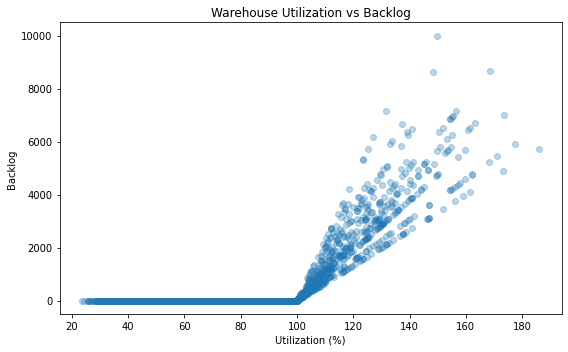

In [23]:
#Question 2 ref:

plt.figure(figsize=(8, 5))

plt.scatter(
    df["utilization_perct"],
    df["backlog"],
    alpha=0.3
)

plt.title("Warehouse Utilization vs Backlog")
plt.xlabel("Utilization (%)")
plt.ylabel("Backlog")

plt.tight_layout()
plt.show()


* backlog generally increases as utilization increases.
thread line to see the relationship

<Figure size 576x360 with 0 Axes>

Text(0.5, 1.0, 'Utilization vs Backlog')

Text(0.5, 0, 'Utilization (%)')

Text(0, 0.5, 'Backlog')

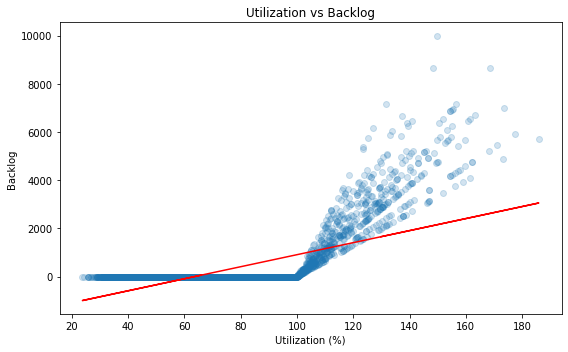

In [24]:
x = df["utilization_perct"]
y = df["backlog"]

slope, intercept = np.polyfit(x, y, 1)

trend_line = slope * x + intercept

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    alpha=0.2
)

plt.plot(
    x,
    trend_line,
    color="red"
)

plt.title("Utilization vs Backlog")
plt.xlabel("Utilization (%)")
plt.ylabel("Backlog")

plt.tight_layout()
plt.show()


In [25]:
df.columns

Index(['date', 'warehouse_id', 'shift_id', 'workers', 'labor_hours',
       'shipments', 'units_procced', 'Productivity', 'capacity',
       'utilization_perct', 'backlog', 'errors', 'errors_percet',
       'on_time_ships_percet', 'late_shipments', 'on_time_ships', 'year',
       'month', 'month_nm', 'day_of_week', 'is_weekend'],
      dtype='object')

In [26]:
df["utilization_band"] = pd.cut(
    df["utilization_perct"],
    bins=[0, 60, 75, 85, 100, float("inf")],
    labels=[
        "Low",
        "Normal",
        "High",
        "Very High",
        "Over Capacity"
    ],
    right=False
)

utilization_analysis = (
    df
    .groupby("utilization_band", observed=True)
    .agg(
        avg_backlog=("backlog", "mean"),
        avg_on_time=("on_time_ships_percet", "mean"),
        avg_error_rate=("errors_percet", "mean"),
        records=("backlog", "size")
    )
    .round(2)
)

utilization_analysis

,avg_backlog,avg_on_time,avg_error_rate,records
utilization_band,,,,
Low,0.00,95.99,0.81,1569
Normal,0.00,96.03,0.80,1359
High,0.00,96.06,0.80,1020
Very High,0.00,95.99,1.11,849
Over Capacity,2074.84,89.59,1.11,678


**Observations**
*  model that identifies capacity pressure, links utilization to backlog and service performance, and creates actionable warehouse KPIs.

* utilisation exceeds 100%

* over capacity >> backlog >>lower on time delivery >> higher error rate

- 85-100% utilization backlog =0 but error inc proportional to utilisation 
- over utilise prop high error rate
- over capacity > backlog appears>on time delibery drops


In [27]:
# Days / Shifts when operation is most under pressure
worst_periods = (
    df[
        [
            "date",
            "warehouse_id",
            "shift_id",
            "shipments",
            "capacity",
            "on_time_ships_percet",
            "backlog",
            "errors",
            "errors_percet",
            "month_nm"
        ]
    ]
    .sort_values(
        "backlog",
        ascending=False
    )
)

worst_periods.head()

,date,warehouse_id,shift_id,shipments,capacity,on_time_ships_percet,backlog,errors,errors_percet,month_nm
5059,2025-12-04,WH02,S2,30160,20160,89.73,10000,274,0.91,December
5076,2025-12-05,WH03,S1,21256,12600,87.52,8656,240,1.13,December
5175,2025-12-12,WH01,S1,26488,17850,88.49,8638,224,0.85,December
5178,2025-12-12,WH02,S1,29832,22680,88.00,7152,333,1.12,December
5061,2025-12-04,WH03,S1,19744,12600,88.03,7144,203,1.03,December


In [28]:
worst_periods.groupby("month_nm").sum().sort_values("backlog", ascending=False)

,shipments,capacity,on_time_ships_percet,backlog,errors,errors_percet
month_nm,,,,,,
December,6711368,6188437,42245.79,1018196,71415,484.52
November,5253384,5988810,42052.30,286274,53748,445.20
October,4712112,6188437,44365.64,38957,44017,431.73
September,4292728,5988810,43059.92,19787,38540,402.37
June,4250160,5988810,43075.60,18232,37949,400.11
May,4420784,6188437,44535.20,16500,39530,413.51
April,4088840,5988810,43160.06,4891,35665,391.54
July,4019880,6188437,44600.02,2446,34042,394.79
March,3916384,6188437,44624.08,1458,32957,391.11


* high shipments observed by the end of the year so is the backlogs

**Q: Which warehousea n shift combination is struggling most?**

In [29]:
shift_summary = (
    df
    .groupby(["warehouse_id", "shift_id"])
    .agg(
        avg_utilization=("utilization_perct", "mean"),
        total_backlog=("backlog", "sum"),
        avg_on_time=("on_time_ships_percet", "mean"),
        avg_error_rate=("errors_percet", "mean"),
        total_shipments=("shipments", "sum")
    )
    .sort_values(
        "total_backlog",
        ascending=False
    )
    .round(2)
)

shift_summary

avg_utilization  total_backlog  avg_on_time  \
warehouse_id shift_id                                                
WH03         S1                  81.70         170192        94.87   
WH05         S1                  82.38         143720        94.89   
WH03         S3                  85.34         141196        94.55   
WH05         S2                  81.59         132744        94.74   
WH03         S2                  78.61         128072        94.92   
WH05         S3                  82.96         102056        94.88   
WH04         S3                  74.41          84829        95.18   
             S1                  70.18          84392        95.53   
WH01         S1                  68.99          73480        95.61   
WH02         S1                  64.96          69312        95.56   
WH01         S3                  70.50          63156        95.41   
             S2                  66.37          59928        95.59   
WH02         S2                  63.99          54144        95.58   
WH04         S2                  67.73          49872        95.52   
WH02         S3                  68.61          49648        95.54   

                       avg_error_rate  total_shipments  
warehouse_id shift_id                                   
WH03         S1                  0.94          3757480  
WH05         S1                  0.94          3182616  
WH03         S3                  0.95          2383040  
WH05         S2                  0.94          2835104  
WH03         S2                  0.91          3271016  
WH05         S3                  0.96          2017976  
WH04         S3                  0.88          2574560  
             S1                  0.85          4058240  
WH01         S1                  0.86          4494856  
WH02         S1                  0.84          5377328  
WH01         S3                  0.86          2825800  
             S2                  0.83          3953488  
WH02         S2                  0.84          4708880  
WH04         S2                  0.85          3567856  
WH02         S3                  0.86          3371824

* W3 has high workload with certain shifts contribute disproportionately to its backlog
* W3S1 is the biggest backlog contributer that is morning shift 

In [30]:
overall_shift_summary = (
    df.groupby("shift_id")
    .agg(
        avg_productivity=("Productivity", "mean"),
        avg_utilization=("utilization_perct", "mean"),
        total_backlog=("backlog", "sum"),
        avg_error_rate=("errors_percet", "mean"),
        avg_on_time=("on_time_ships_percet", "mean")
    )
    .round(2)
)

overall_shift_summary

,avg_productivity,avg_utilization,total_backlog,avg_error_rate,avg_on_time
shift_id,,,,,
S1,7.71,73.64,541096,0.89,95.29
S2,7.14,71.66,424760,0.88,95.27
S3,6.48,76.37,440885,0.90,95.11


note: deliberately gave the night shift a lower productivity multiplier earlier

**Observations**
* W3 S1, S2, S3 are responsible for major part of backlogs
* W3 Night shift less productive 
* S3 is most pressured shift too
* Therefore S3 has : lowerst productivity, highest utilisation, high error rate, low on time deliveries

*S3(Night shift) shows highest operational pressure weaker performance*
---------
* W3/W5 experience highest capacity pressure 
|
* Certain shifts W3S1, W5S1 contribute disproportionately
|
* Over-capacity periods create backlog(utilisation analysis)
|
* Backlog reduces on-time delivery
|
* High utilization increases error rate
|
* *Recommendation : Review staffing/capacity allocation during peak periods*

**W3S3 and W2S1**

# KPI Summary

In [31]:
df.columns

Index(['date', 'warehouse_id', 'shift_id', 'workers', 'labor_hours',
       'shipments', 'units_procced', 'Productivity', 'capacity',
       'utilization_perct', 'backlog', 'errors', 'errors_percet',
       'on_time_ships_percet', 'late_shipments', 'on_time_ships', 'year',
       'month', 'month_nm', 'day_of_week', 'is_weekend', 'utilization_band'],
      dtype='object')

In [32]:
kpi_summary = pd.DataFrame({
"KPI": [
"Total Shipments",
"Average Productivity",
"Average Utilization",
"Total Backlog",
"Total Errors",
"Average Error Rate",
"Average On-Time Delivery"
],
"Value": [
df["shipments"].sum(),
df["Productivity"].mean(),
df["utilization_perct"].mean(),
df["backlog"].sum(),
df["errors"].sum(),
df["errors_percet"].mean(),
df["on_time_ships_percet"].mean()
]
})

kpi_summary

,KPI,Value
0,Total Shipments,5.238006e+07
1,Average Productivity,7.107944e+00
2,Average Utilization,7.388946e+01
3,Total Backlog,1.406741e+06
4,Total Errors,4.758050e+05
5,Average Error Rate,8.884457e-01
6,Average On-Time Delivery,9.522378e+01


In [33]:
kpi_summary_formatted = pd.DataFrame({
"KPI": [
"Total Shipments",
"Average Productivity",
"Average Utilization",
"Total Backlog",
"Total Errors",
"Average Error Rate",
"Average On-Time Delivery"
],
"Value": [
f"{df['shipments'].sum():,.0f}",
f"{df['Productivity'].mean():.2f}",
f"{df['utilization_perct'].mean():.2f}%",
f"{df['backlog'].sum():,.0f}",
f"{df['errors'].sum():,.0f}",
f"{df['errors_percet'].mean():.2f}%",
f"{df['on_time_ships_percet'].mean():.2f}%"
]
})

kpi_summary_formatted


,KPI,Value
0,Total Shipments,"52,380,064"
1,Average Productivity,7.11
2,Average Utilization,73.89%
3,Total Backlog,"1,406,741"
4,Total Errors,"475,805"
5,Average Error Rate,0.89%
6,Average On-Time Delivery,95.22%


In [34]:
warehouse_dashboard = (
df.groupby("warehouse_id").agg(
shipments=("shipments", "sum"),
avg_productivity=("Productivity", "mean"),
avg_utilization=("utilization_perct", "mean"),
backlog=("backlog", "sum"),
errors=("errors", "sum"),
error_rate=("errors_percet", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
).round(2)
)

warehouse_dashboard


,shipments,avg_productivity,avg_utilization,backlog,errors,error_rate,on_time_delivery
warehouse_id,,,,,,,
WH01,11274144,7.04,68.62,196564,98741,0.85,95.54
WH02,13458032,7.14,65.85,173104,116794,0.85,95.56
WH03,9411536,7.40,81.89,439460,91001,0.93,94.78
WH04,10200656,6.99,70.78,219093,90266,0.86,95.41
WH05,8035696,6.96,82.31,378520,79003,0.95,94.84


In [35]:
#for dashboards
warehouse_dashboard.to_csv(
"/Volumes/DATA/logist/data/processed/warehouse_dashboard.csv"
)

kpi_summary_formatted.to_csv(
"/Volumes/DATA/logist/data/processed/kpi_summary.csv",
index=False
)

print("Dashboard tables saved.")



Dashboard tables saved.


- Analysed warehouse, shifts, capacity/volume, utilisation, backlog, quality, service offered(shipments, deliveries, backlogs)

**Analsyse wrt to Month, Week, Peak hours** for major operational considerations

In [36]:
df.head()

,date,warehouse_id,shift_id,workers,labor_hours,shipments,units_procced,Productivity,capacity,utilization_perct,...,errors_percet,on_time_ships_percet,late_shipments,on_time_ships,year,month,month_nm,day_of_week,is_weekend,utilization_band
0,2025-01-01,WH01,S1,25,200,11752,23504,7.345000,17850,65.84,...,0.84,96.39,424,11328,2025,1,January,Wednesday,False,Normal
1,2025-01-01,WH01,S2,24,192,10112,10112,6.583333,16320,61.96,...,0.73,94.30,577,9535,2025,1,January,Wednesday,False,Normal
2,2025-01-01,WH01,S3,19,152,7488,14976,6.157895,10982,68.18,...,0.92,94.96,377,7111,2025,1,January,Wednesday,False,Normal
3,2025-01-01,WH02,S1,30,240,14048,28096,7.316667,22680,61.94,...,0.76,97.15,400,13648,2025,1,January,Wednesday,False,Normal
4,2025-01-01,WH02,S2,28,224,10936,10936,6.102679,20160,54.25,...,0.94,95.79,460,10476,2025,1,January,Wednesday,False,Low


In [37]:
# 75 Monthly Performance
monthly_summary = (
df.groupby(["month","month_nm"]).agg(
shipments=("shipments", "sum"),
avg_utilization=("utilization_perct", "mean"),
backlog=("backlog", "sum"),
errors=("errors", "sum"),
on_time_delivery=("on_time_ships_percet", "mean")
)
)
monthly_summary

,,shipments,avg_utilization,backlog,errors,on_time_delivery
month,month_nm,,,,,
1,January,3809576,63.185355,0,31512,96.031161
2,February,3186288,58.604119,0,25472,96.014095
3,March,3916384,65.038559,1458,32957,95.965763
4,April,4088840,70.122067,4891,35665,95.911244
5,May,4420784,73.355441,16500,39530,95.774624
6,June,4250160,73.147000,18232,37949,95.723556
7,July,4019880,66.763011,2446,34042,95.914022
8,August,3718560,61.761806,0,30958,96.024086
9,September,4292728,73.633400,19787,38540,95.688711


In [38]:
# busiest month
monthly_summary["shipments"].idxmax()
#which month procedd the highest volume
monthly_summary["shipments"].max()
# which month worst backlog month
monthly_summary["backlog"].idxmax()
monthly_summary["backlog"].max()

#worst service month
monthly_summary["on_time_delivery"].idxmin()
monthly_summary["on_time_delivery"].min()
#month with high utilization
monthly_summary["avg_utilization"].idxmax()
monthly_summary["avg_utilization"].max()



(12, 'December')

6711368

(12, 'December')

1018196

(12, 'December')

90.85116129032258

(12, 'December')

111.39507526881721

<AxesSubplot:title={'center':'Monthly Shipment Volume'}, xlabel='month,month_nm'>

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Shipments')

<AxesSubplot:title={'center':'Monthly Backlog'}, xlabel='month,month_nm'>

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Total Backlog')

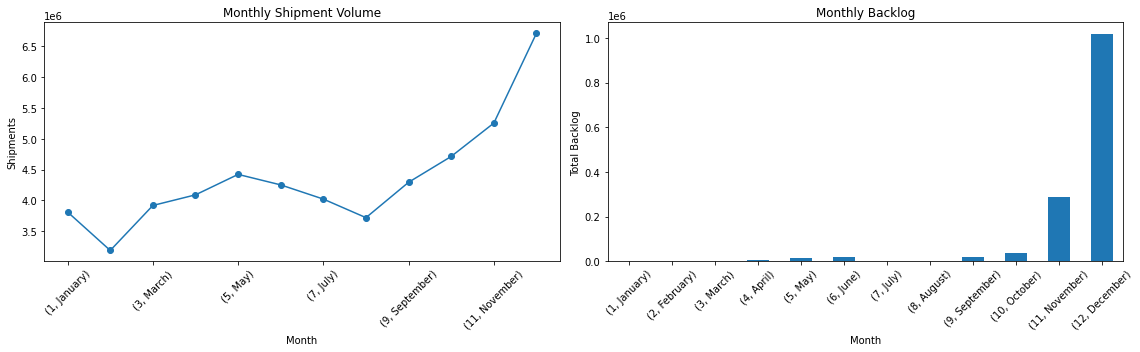

In [39]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly Shipment Volume
monthly_summary["shipments"].plot(
    kind="line",
    ax=axes[0],
    marker="o",
    title="Monthly Shipment Volume"
)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Shipments")
axes[0].tick_params(axis="x", rotation=45)

# Monthly Backlog
monthly_summary["backlog"].plot(
    kind="bar",
    ax=axes[1],
    title="Monthly Backlog"
)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Total Backlog")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()



**weekday perormance**

In [40]:
#Does operational performance differ depending on the day of the week?
weekday_order = [
"Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday",
"Saturday",
"Sunday"
]


weekday_summary = (
df
.groupby("day_of_week")
.agg(
shipments=("shipments", "sum"),
avg_utilization=("utilization_perct", "mean"),
backlog=("backlog", "sum"),
error_rate=("errors_percet", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
)
.reindex(weekday_order)
.round(2)
)

weekday_summary

,shipments,avg_utilization,backlog,error_rate,on_time_delivery
day_of_week,,,,,
Monday,8617832,85.24,291319,0.93,94.78
Tuesday,8173304,81.07,236015,0.90,95.10
Wednesday,8384432,81.36,233769,0.90,95.08
Thursday,8537848,84.44,262394,0.92,94.98
Friday,8892856,88.19,382766,0.95,94.64
Saturday,5278400,52.27,478,0.81,96.02
Sunday,4495392,44.51,0,0.81,95.99


* there is an operation diff b/w high shipments vol weekdays and on weekends
* high shipments weekdays show greater peasure and weaker performance i.e on time deliv +backlogs+errors compared to weekends

'Friday'

'Friday'

'Friday'

'Friday'

<AxesSubplot:title={'center':'Backlog by Day of Week'}, xlabel='day_of_week'>

Text(0.5, 0, 'Day')

Text(0, 0.5, 'Total Backlog')

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

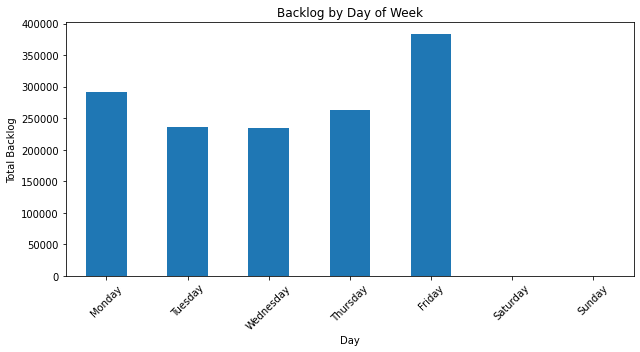

False    3948
True     1527
Name: is_peak, dtype: int64

In [41]:
#worst weekday based on hugh volume backlog utilisation and on time delivery 

weekday_summary["shipments"].idxmax()
weekday_summary["backlog"].idxmax()
weekday_summary["avg_utilization"].idxmax()
weekday_summary["on_time_delivery"].idxmin()

#Are certain days operationally more difficult?


#weekday backlog

weekday_summary["backlog"].plot(
kind="bar",
figsize=(9, 5),
title="Backlog by Day of Week"
)

plt.xlabel("Day")
plt.ylabel("Total Backlog")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#create a simple business definition of a peak operational period.

#A shift is considered a peak period when utilization exceeds 85%.


df["is_peak"] = (
df["utilization_perct"] > 85)
df["is_peak"].value_counts()



In [42]:
#Peak vs non peak

peak_summary = (
df.groupby("is_peak").agg(
shipments=("shipments", "mean"),
utilization=("utilization_perct", "mean"),
backlog=("backlog", "mean"),
errors=("errors", "mean"),
error_rate=("errors_percet", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
).round(2))

peak_summary

,shipments,utilization,backlog,errors,error_rate,on_time_delivery
is_peak,,,,,,
False,8645.22,62.42,0.00,69.28,0.80,96.03
True,11950.71,103.54,921.24,132.48,1.11,93.15


* when operations goes into peak / over peak conditions capacity inc., utilisation =103%, backlog starts, error inc. 

In [43]:
#peak_periods 
df["is_peak"].value_counts()


False    3948
True     1527
Name: is_peak, dtype: int64

**debug December peak month**

* looking at montly_summary dec is the peak seasonal demand period.(holiday season too)

In [44]:
#highest simplment volume
monthly_summary.sort_values("shipments",ascending=False).head()
#high util wrt month
monthly_summary.sort_values("avg_utilization",ascending=False).head()
#worst time deliv
monthly_summary.sort_values("on_time_delivery",ascending=False).head()


,,shipments,avg_utilization,backlog,errors,on_time_delivery
month,month_nm,,,,,
12,December,6711368,111.395075,1018196,71415,90.851161
11,November,5253384,90.461889,286274,53748,93.449556
10,October,4712112,78.107376,38957,44017,95.409978
5,May,4420784,73.355441,16500,39530,95.774624
9,September,4292728,73.633400,19787,38540,95.688711


,,shipments,avg_utilization,backlog,errors,on_time_delivery
month,month_nm,,,,,
12,December,6711368,111.395075,1018196,71415,90.851161
11,November,5253384,90.461889,286274,53748,93.449556
10,October,4712112,78.107376,38957,44017,95.409978
9,September,4292728,73.633400,19787,38540,95.688711
5,May,4420784,73.355441,16500,39530,95.774624


,,shipments,avg_utilization,backlog,errors,on_time_delivery
month,month_nm,,,,,
1,January,3809576,63.185355,0,31512,96.031161
8,August,3718560,61.761806,0,30958,96.024086
2,February,3186288,58.604119,0,25472,96.014095
3,March,3916384,65.038559,1458,32957,95.965763
7,July,4019880,66.763011,2446,34042,95.914022


In [45]:
#The warehouse most effected by peak hours
peak_warehouse = (
df[df["is_peak"]].groupby("warehouse_id").agg(
shipments=("shipments", "sum"),
avg_utilization=("utilization_perct", "mean"),
backlog=("backlog", "sum"),
error_rate=("errors_percet", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
).sort_values(
"backlog",
ascending=False
).round(2))
peak_warehouse


,shipments,avg_utilization,backlog,error_rate,on_time_delivery
warehouse_id,,,,,
WH03,5137008,104.26,439460,1.10,93.21
WH05,4532096,103.97,378520,1.12,93.44
WH04,2805856,103.90,219093,1.11,92.75
WH01,2820104,102.49,196564,1.10,92.92
WH02,2953672,100.86,173104,1.11,92.91


In [46]:
#90 worst shift timing in peak
peak_shift = (
df[df["is_peak"]]
.groupby("shift_id")
.agg(
shipments=("shipments", "sum"),
avg_productivity=("Productivity", "mean"),
avg_utilization=("utilization_perct", "mean"),
backlog=("backlog", "sum"),
error_rate=("errors_percet", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
).sort_values(
"backlog",
ascending=False
).round(2))
peak_shift

,shipments,avg_productivity,avg_utilization,backlog,error_rate,on_time_delivery
shift_id,,,,,,
S1,7236448,10.42,103.07,541096,1.11,93.24
S3,5278840,8.59,104.20,440885,1.11,93.20
S2,5733448,9.89,103.22,424760,1.11,92.99


In [47]:
#warehouse+shift
peak_warehouse_shift = (
df[df["is_peak"]].groupby(["warehouse_id", "shift_id"]).agg(
shipments=("shipments", "sum"),
avg_productivity=("Productivity", "mean"),
avg_utilization=("utilization_perct", "mean"),
backlog=("backlog", "sum"),
error_rate=("errors_percet", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
).sort_values(
"backlog",
ascending=False
).round(2))

peak_warehouse_shift.head()

,,shipments,avg_productivity,avg_utilization,backlog,error_rate,on_time_delivery
warehouse_id,shift_id,,,,,,
WH03,S1,2096920,10.18,103.37,170192,1.10,93.39
WH05,S1,1779816,9.54,103.80,143720,1.12,93.46
WH03,S3,1493968,8.41,105.56,141196,1.10,93.13
WH05,S2,1592880,9.09,103.93,132744,1.11,93.25
WH03,S2,1546120,9.71,103.53,128072,1.11,93.09


* W3S1 remains the same effected matching shift_summary output

<AxesSubplot:title={'center':'On-Time Delivery by Day of Week'}, xlabel='day_of_week'>

Text(0.5, 0, 'Day')

Text(0, 0.5, 'On-Time Delivery (%)')

<AxesSubplot:title={'center':'Operational Performance: Peak vs Normal'}, xlabel='is_peak'>

Text(0.5, 0, 'Peak Period')

Text(0, 0.5, 'Value')

[Text(0, 0, 'Normal'), Text(1, 0, 'Peak')]

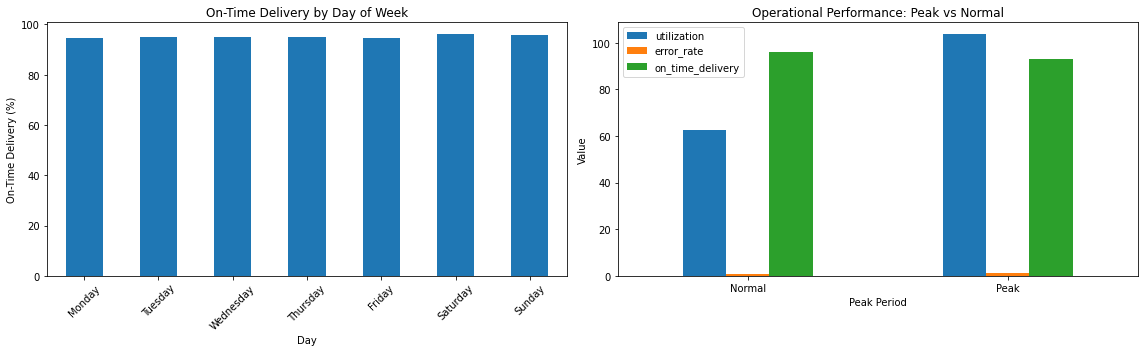

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# On-Time Delivery by Day of Week
weekday_summary["on_time_delivery"].plot(
    kind="bar",
    ax=axes[0],
    title="On-Time Delivery by Day of Week"
)

axes[0].set_xlabel("Day")
axes[0].set_ylabel("On-Time Delivery (%)")
axes[0].tick_params(axis="x", rotation=45)


# Peak vs Normal Performance
peak_chart = peak_summary[
    [
        "utilization",
        "error_rate",
        "on_time_delivery"
    ]
]

peak_chart.plot(
    kind="bar",
    ax=axes[1],
    title="Operational Performance: Peak vs Normal"
)

axes[1].set_xlabel("Peak Period")
axes[1].set_ylabel("Value")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Normal", "Peak"], rotation=0)


plt.tight_layout()
plt.show()


In [85]:
df.columns

Index(['date', 'warehouse_id', 'shift_id', 'workers', 'labor_hours',
       'shipments', 'units_procced', 'Productivity', 'capacity',
       'utilization_perct', 'backlog', 'errors', 'errors_percet',
       'on_time_ships_percet', 'late_shipments', 'on_time_ships', 'year',
       'month', 'month_nm', 'day_of_week', 'is_weekend', 'utilization_band',
       'is_peak', 'backlog_rate_pct', 'high_pressure'],
      dtype='object')

**Recommendation 1 - Peak vol planning** 
* Prioritize capacity and staffing planning for peak periods, particularly at high-utilization warehouses. The analysis indicates that peak periods are associated with increased backlog, higher error rates and lower on-time delivery. 

**Recommendation 2 — Shift level intervention**
* Review staffing and process conditions for S1, which shows the lowest productivity and highest utilization among shifts. 

**Recommendation 3 — Peak season Prep**
* Use historical/forecasted volume to pre-position labor capacity before expected peak periods rather than reacting after backlog has accumulated.

In [49]:
peak_warehouse
peak_shift
peak_warehouse_shift

,shipments,avg_utilization,backlog,error_rate,on_time_delivery
warehouse_id,,,,,
WH03,5137008,104.26,439460,1.10,93.21
WH05,4532096,103.97,378520,1.12,93.44
WH04,2805856,103.90,219093,1.11,92.75
WH01,2820104,102.49,196564,1.10,92.92
WH02,2953672,100.86,173104,1.11,92.91


,shipments,avg_productivity,avg_utilization,backlog,error_rate,on_time_delivery
shift_id,,,,,,
S1,7236448,10.42,103.07,541096,1.11,93.24
S3,5278840,8.59,104.20,440885,1.11,93.20
S2,5733448,9.89,103.22,424760,1.11,92.99


shipments  avg_productivity  avg_utilization  backlog  \
warehouse_id shift_id                                                          
WH03         S1          2096920             10.18           103.37   170192   
WH05         S1          1779816              9.54           103.80   143720   
WH03         S3          1493968              8.41           105.56   141196   
WH05         S2          1592880              9.09           103.93   132744   
WH03         S2          1546120              9.71           103.53   128072   
WH05         S3          1159400              7.75           104.18   102056   
WH04         S3           917192              9.16           105.17    84829   
             S1          1024880             11.23           104.35    84392   
WH01         S1          1185472             11.23           100.63    73480   
WH02         S1          1149360             11.97           101.36    69312   
WH01         S3           807784              9.36           103.60    63156   
             S2           826848             10.99           103.40    59928   
WH02         S2           903816             11.46           101.89    54144   
WH04         S2           863784             10.40           101.44    49872   
WH02         S3           900496              9.55            99.82    49648   

                       error_rate  on_time_delivery  
warehouse_id shift_id                                
WH03         S1              1.10             93.39  
WH05         S1              1.12             93.46  
WH03         S3              1.10             93.13  
WH05         S2              1.11             93.25  
WH03         S2              1.11             93.09  
WH05         S3              1.14             93.60  
WH04         S3              1.12             92.78  
             S1              1.11             92.66  
WH01         S1              1.11             93.43  
WH02         S1              1.11             92.49  
WH01         S3              1.09             92.71  
             S2              1.09             92.52  
WH02         S2              1.11             92.55  
WH04         S2              1.10             92.80  
WH02         S3              1.10             93.47

* W3 has largest peak backlog, W4 worst peak time performance
* S1 has most backlog and worst performance but it also has more shipments (rates ar eimp than totals)
* W3 S3 has high util+low productivity + backlogs+weaker performance

* Backlog rate to analyse more (why?= to have an idea including shipments and backlogs)


In [50]:
# 96 backlog rate normalised KPIs
df["backlog_rate_pct"] = (
df["backlog"]
/ df["shipments"]
* 100
).round(2)


df[[
"warehouse_id",
"shift_id",
"shipments",
"backlog",
"backlog_rate_pct"
]].head()


,warehouse_id,shift_id,shipments,backlog,backlog_rate_pct
0,WH01,S1,11752,0,0.0
1,WH01,S2,10112,0,0.0
2,WH01,S3,7488,0,0.0
3,WH02,S1,14048,0,0.0
4,WH02,S2,10936,0,0.0


In [51]:
# backlog rate wrt warehouse to chk actual pressured warehouse

warehouse_backlog_rate = (
df.groupby("warehouse_id").agg(
shipments=("shipments", "sum"),
backlog=("backlog", "sum"),
backlog_rate=("backlog_rate_pct", "mean"),
utilization=("utilization_perct", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
).sort_values(
"backlog_rate",
ascending=False).round(2))

warehouse_backlog_rate


,shipments,backlog,backlog_rate,utilization,on_time_delivery
warehouse_id,,,,,
WH03,9411536,439460,2.93,81.89,94.78
WH05,8035696,378520,2.91,82.31,94.84
WH04,10200656,219093,1.29,70.78,95.41
WH01,11274144,196564,1.00,68.62,95.54
WH02,13458032,173104,0.72,65.85,95.56


* W3 and W5 are the top 2 effected warehouses with good amt of backlog%

In [52]:
peak_backlog_rate = (
df[df["is_peak"]].groupby("warehouse_id").agg(
shipments=("shipments", "sum"),
backlog=("backlog", "sum"),
backlog_rate=("backlog_rate_pct", "mean"),
utilization=("utilization_perct", "mean"),
on_time_delivery=("on_time_ships_percet", "mean")
).sort_values(
"backlog_rate",
ascending=False).round(2))

peak_backlog_rate


,shipments,backlog,backlog_rate,utilization,on_time_delivery
warehouse_id,,,,,
WH03,5137008,439460,6.74,104.26,93.21
WH04,2805856,219093,6.65,103.90,92.75
WH05,4532096,378520,6.51,103.97,93.44
WH01,2820104,196564,5.91,102.49,92.92
WH02,2953672,173104,4.90,100.86,92.91


* W4 vulnerable to peak period service degradation as backlog %6.65 and on time is just 92.75% 

**pressure score**

* Shift is considered on high pressured : util>100%, backlog>0, on time deliv<95%

In [53]:
df["high_pressure"] = ((df["utilization_perct"] > 100)&(df["backlog"] > 0)&(df["on_time_ships_percet"] < 95))

# no. Of operational records experiencing all three
df["high_pressure"].value_counts()


False    4858
True      617
Name: high_pressure, dtype: int64

In [54]:
high_pressure_percet=(df["high_pressure"].mean()*100)
high_pressure_percet

11.269406392694064

* almost 11.3% of the records observe good high pressure 

In [55]:
#100 high pressur periods 
high_pressure_summary = (df[df["high_pressure"]].groupby("warehouse_id").agg(
high_pressure_periods=("high_pressure", "size"),
shipments=("shipments", "sum"),
backlog=("backlog", "sum"),
avg_utilization=("utilization_perct", "mean"),
avg_on_time=("on_time_ships_percet", "mean"),
avg_error_rate=("errors_percet", "mean")
).sort_values(
"high_pressure_periods",
ascending=False).round(2))

high_pressure_summary

,high_pressure_periods,shipments,backlog,avg_utilization,avg_on_time,avg_error_rate
warehouse_id,,,,,,
WH03,190,2376672,437322,122.62,88.93,1.10
WH05,182,2013192,376312,123.39,89.13,1.11
WH04,96,1429272,218709,118.44,88.89,1.10
WH01,81,1371584,195966,116.66,88.67,1.11
WH02,68,1443424,172768,113.83,88.60,1.10


* W3 and W5 observe high pressure periods with avg util is >120%

In [56]:
#warehouses % of periods become high pressure
pressure_by_warehouse = (df.groupby("warehouse_id").agg(
total_periods=("high_pressure", "size"),
high_pressure_periods=("high_pressure", "sum")))

pressure_by_warehouse["high_pressure_percet"] = (
pressure_by_warehouse["high_pressure_periods"]
/ pressure_by_warehouse["total_periods"]* 100)

pressure_by_warehouse.sort_values(
"high_pressure_percet",
ascending=False
).round(2)

,total_periods,high_pressure_periods,high_pressure_percet
warehouse_id,,,
WH03,1095,190,17.35
WH05,1095,182,16.62
WH04,1095,96,8.77
WH01,1095,81,7.40
WH02,1095,68,6.21


In [57]:
#102
final_warehouse_scorecard = (df.groupby("warehouse_id").agg(
shipments=("shipments", "sum"),
avg_productivity=("Productivity", "mean"),
avg_utilization=("utilization_perct", "mean"),
backlog=("backlog", "sum"),
backlog_rate=("backlog_rate_pct", "mean"),
error_rate=("errors_percet", "mean"),
on_time_delivery=("on_time_ships_percet", "mean"),
high_pressure_periods=("high_pressure", "sum")).round(2))

final_warehouse_scorecard




final_warehouse_scorecard["high_pressure_percet"] = (
final_warehouse_scorecard["high_pressure_periods"]
/ df.groupby("warehouse_id").size()* 100).round(2)

final_warehouse_scorecard.sort_values("high_pressure_percet",ascending=False)

,shipments,avg_productivity,avg_utilization,backlog,backlog_rate,error_rate,on_time_delivery,high_pressure_periods
warehouse_id,,,,,,,,
WH01,11274144,7.04,68.62,196564,1.00,0.85,95.54,81
WH02,13458032,7.14,65.85,173104,0.72,0.85,95.56,68
WH03,9411536,7.40,81.89,439460,2.93,0.93,94.78,190
WH04,10200656,6.99,70.78,219093,1.29,0.86,95.41,96
WH05,8035696,6.96,82.31,378520,2.91,0.95,94.84,182


,shipments,avg_productivity,avg_utilization,backlog,backlog_rate,error_rate,on_time_delivery,high_pressure_periods,high_pressure_percet
warehouse_id,,,,,,,,,
WH03,9411536,7.40,81.89,439460,2.93,0.93,94.78,190,17.35
WH05,8035696,6.96,82.31,378520,2.91,0.95,94.84,182,16.62
WH04,10200656,6.99,70.78,219093,1.29,0.86,95.41,96,8.77
WH01,11274144,7.04,68.62,196564,1.00,0.85,95.54,81,7.40
WH02,13458032,7.14,65.85,173104,0.72,0.85,95.56,68,6.21


**OBSERVATIONS**

* WH03 is the highest-risk warehouse
* It has:
- 2.93% backlog rate — highest
- 17.35% high-pressure periods — highest
- 81.89% average utilization
- 7.40 productivity — highest
- 94.78% on-time delivery

WH03 is highly productive, but still experiences the greatest capacity/backlog pressure.

*That quotes productivity alone isn’t solving the capacity problem.*

* WH05 is also under significant pressure
WH05:
- 2.91% backlog rate
- 16.62% high-pressure periods
- 82.31% utilization — highest overall
- 6.96 productivity
- 94.84% on-time

*WH03 + WH05 to be studied.*

* WH02 is the benchmark
* WH02 processes the largest shipment volume: 13.46M, yet has:
- only 0.72% backlog rate
- 6.21% high-pressure periods — lowest
- 65.85% utilization
- 95.56% on-time delivery


*“What operational practices allow WH02 to handle the highest volume with the lowest backlog rate?”=> To be studied*


_____________________________

* The analysis identifies volume pressure as a major operational risk. 
* Peak periods are associated with utilization above capacity, increased backlog and errors, and reduced on-time delivery. 
* WH03 and WH05 experience the highest relative backlog pressure, while WH04 shows particularly weak service performance during peak periods. 
* Shift S3 also shows the lowest productivity and highest utilization overall.



In [58]:
final_warehouse_scorecard.to_csv("/Volumes/DATA/logist/data/processed/warehouse_scorecard.csv")



In [59]:
#104

## Q1: Which warehouses experience the greatest operational pressure?

**Objective**

Warehouses with the highest capacity pressure, backlog rates, and frequency of high-pressure periods.

**Key findings**

- WH03 has the highest backlog rate at 2.93%.
- WH05 has the second-highest backlog rate at 2.91%.
- WH03 has the highest proportion of high-pressure periods at 17.35%.
- WH05 follows at 16.62%.
- WH02 processes the highest shipment volume but has the lowest backlog rate (0.72%) and lowest high-pressure frequency (6.21%).

**Interpretation**

WH03 and WH05 appear to experience greater capacity pressure relative to their shipment volumes. WH02 provides a useful benchmark because it processes the highest volume while maintaining the lowest backlog rate and high-pressure frequency.

**Recommendation**

Investigate differences in staffing, process design, workload distribution, and shift performance between WH02 and the higher-pressure warehouses.


<AxesSubplot:title={'center':'Backlog Rate by Warehouse'}, xlabel='warehouse_id'>

Text(0.5, 0, 'Warehouse')

Text(0, 0.5, 'Backlog Rate (%)')

<AxesSubplot:title={'center':'High-Pressure Periods by Warehouse'}, xlabel='warehouse_id'>

Text(0.5, 0, 'Warehouse')

Text(0, 0.5, 'High-Pressure Periods (%)')

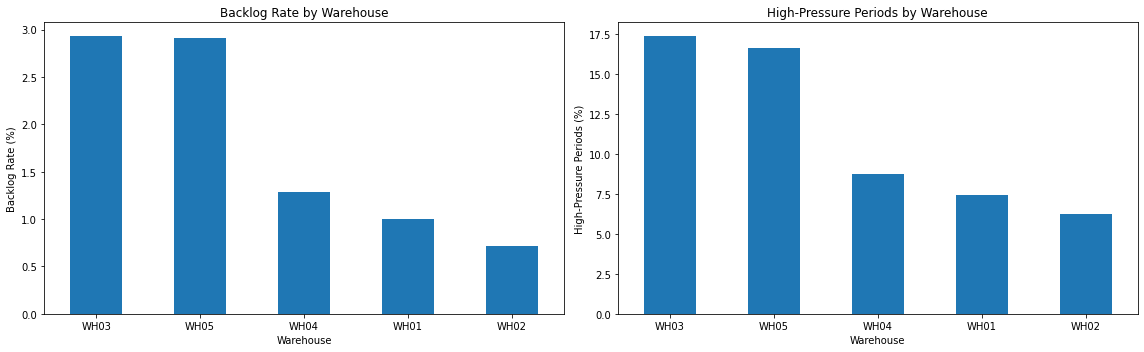

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Backlog Rate by Warehouse
warehouse_backlog_rate_chart = (
    final_warehouse_scorecard["backlog_rate"]
    .sort_values(ascending=False)
)

warehouse_backlog_rate_chart.plot(
    kind="bar",
    ax=axes[0],
    title="Backlog Rate by Warehouse"
)

axes[0].set_xlabel("Warehouse")
axes[0].set_ylabel("Backlog Rate (%)")
axes[0].tick_params(axis="x", rotation=0)


# High-Pressure Periods

pressure_chart = (
    final_warehouse_scorecard["high_pressure_percet"]
    .sort_values(ascending=False)
)

pressure_chart.plot(
    kind="bar",
    ax=axes[1],
    title="High-Pressure Periods by Warehouse"
)

axes[1].set_xlabel("Warehouse")
axes[1].set_ylabel("High-Pressure Periods (%)")
axes[1].tick_params(axis="x", rotation=0)


# Layout
plt.tight_layout()
plt.show()


In [61]:
#comparing W2,W3, W5
benchmark = final_warehouse_scorecard.loc[
["WH02", "WH03", "WH05"],
[
"shipments",
"avg_productivity",
"avg_utilization",
"backlog_rate",
"error_rate",
"on_time_delivery",
"high_pressure_percet"
]
]

benchmark

,shipments,avg_productivity,avg_utilization,backlog_rate,error_rate,on_time_delivery,high_pressure_percet
warehouse_id,,,,,,,
WH02,13458032,7.14,65.85,0.72,0.85,95.56,6.21
WH03,9411536,7.40,81.89,2.93,0.93,94.78,17.35
WH05,8035696,6.96,82.31,2.91,0.95,94.84,16.62


* I analyzed simulated warehouse operations and identified W3 and W5 as the highest-pressure locations. 
* W2 processes the highest volume while maintaining the lowest backlog rate and high-pressure frequency. I therefore used W2 as a benchmark to investigate which operational factors may explain the difference.

Note: we cannot say W2 is better as no sufficient dara has been presented over staffing policy, conveyer config, management practices, layout, automation level, training, and package mix. It indeed has a better performance in comparison

# Q2: Higher utilisation leading to bhigher backlog?

* To use for analysis: corr, scatter plot, trend line, comparison util brands, stratisticsl significance test


In [62]:
#Corr
util_corr = df[
["utilization_perct", "backlog"]].corr()

util_corr

#scatter plot & trend  already plotted -  Question 2 ref

,utilization_perct,backlog
utilization_perct,1.000000,0.655329
backlog,0.655329,1.000000


In [63]:
# to analyse the relation using pearsonr

from scipy.stats import pearsonr

In [64]:
r, p =pearsonr(df["utilization_perct"],df["backlog"])
print(r,f"{p:.20f}")

0.6553289311497706 0.00000000000000000000


* as p < 0.005 i.e:0 so there is statistically significant relationship
* there is indeer a +ve relation, warehouse util inc, backlog inc. (proportional); but util doesn't cause backlog

**Analysis**

A Pearson correlation was calculated between utilization percentage and backlog.

- Pearson correlation (r): 0.655
- Statistical significance: p < 0.001

**finding**

There is a moderately strong positive relationship between utilization and backlog. Higher utilization levels are associated with higher backlog in the simulated operational dataset.

**Interpretation**

The relationship suggests that capacity pressure is an important factor associated with backlog accumulation. As utilization increases, the operation has less available capacity to absorb additional workload.

**Limitation**

Correlation does not establish causation. Other operational factors, such as staffing, workload mix, process efficiency, or shift-level differences, could also contribute to backlog.

**implication**

Monitoring utilization can provide an early warning signal for potential backlog accumulation. Capacity planning and resource allocation should therefore be considered before utilization reaches sustained over-capacity levels.


**To analyse which operation KPIs are related to each other**

In [65]:
# Variables we want to test
variables = {
"Utilization vs Backlog": (
"utilization_perct",
"backlog"
),
"Utilization vs Error Rate": (
"utilization_perct",
"errors_percet"
),
"Utilization vs On-Time Delivery": (
"utilization_perct",
"on_time_ships_percet"
),
"Productivity vs Backlog": (
"Productivity",
"backlog"
),
"Productivity vs On-Time Delivery": (
"Productivity",
"on_time_ships_percet"
),
"Backlog vs On-Time Delivery": (
"backlog",
"on_time_ships_percet"
)
}

results = []

for relationship, (x_col, y_col) in variables.items():

# Remove missing values
    data = df[[x_col, y_col]].dropna()

# Pearson correlation + p-value
    r, p = pearsonr(
    data[x_col],
    data[y_col]
    )

    results.append({
        "Relationship": relationship,
        "Correlation_r": r,
        "P_Value": p
    })

correlation_analysis = pd.DataFrame(results)

# Add interpretation of correlation strength
def correlation_strength(r):
    r_abs = abs(r)

    if r_abs < 0.20:
        return "Very weak"
    elif r_abs < 0.40:
        return "Weak"
    elif r_abs < 0.60:
        return "Moderate"
    elif r_abs < 0.80:
        return "Strong"
    else:
        return "Very strong"


correlation_analysis["Strength"] = (correlation_analysis["Correlation_r"].apply(correlation_strength))

# Statistical significance
correlation_analysis["Significant"] = (correlation_analysis["P_Value"] < 0.05)

# Round values for readability
correlation_analysis["Correlation_r"] = (correlation_analysis["Correlation_r"].round(3))

correlation_analysis["P_Value"] = (correlation_analysis["P_Value"].apply(lambda x: f"{x:.2e}"))

correlation_analysis

,Relationship,Correlation_r,P_Value,Strength,Significant
0,Utilization vs Backlog,0.655,0.00e+00,Strong,True
1,Utilization vs Error Rate,0.530,0.00e+00,Moderate,True
2,Utilization vs On-Time Delivery,-0.634,0.00e+00,Strong,True
3,Productivity vs Backlog,0.638,0.00e+00,Strong,True
4,Productivity vs On-Time Delivery,-0.586,0.00e+00,Moderate,True
5,Backlog vs On-Time Delivery,-0.764,0.00e+00,Strong,True


In [66]:
#Corr

correlation_matrix = df[
[
"utilization_perct",
"Productivity",
"backlog",
"errors_percet",
"on_time_ships_percet",
"shipments"
]
].corr()

correlation_matrix.round(2)

,utilization_perct,Productivity,backlog,errors_percet,on_time_ships_percet,shipments
utilization_perct,1.00,0.92,0.66,0.53,-0.63,0.57
Productivity,0.92,1.00,0.64,0.46,-0.59,0.84
backlog,0.66,0.64,1.00,0.32,-0.76,0.45
errors_percet,0.53,0.46,0.32,1.00,-0.37,0.25
on_time_ships_percet,-0.63,-0.59,-0.76,-0.37,1.00,-0.38
shipments,0.57,0.84,0.45,0.25,-0.38,1.00


<Figure size 648x504 with 0 Axes>

<AxesSubplot:>

Text(0.5, 1.0, 'Operational KPI Correlation Matrix')

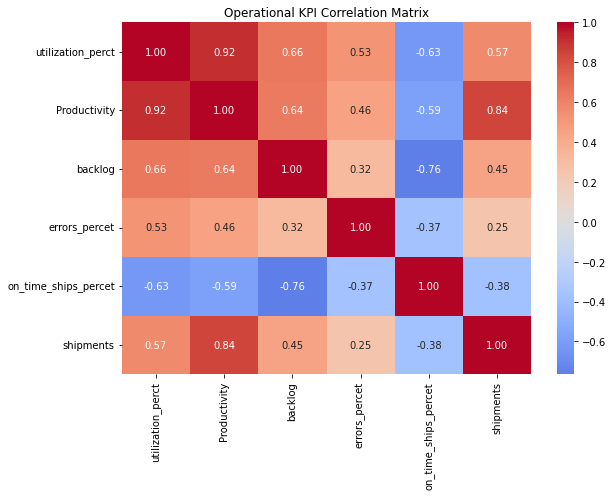

In [67]:
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
correlation_matrix,
annot=True,
fmt=".2f",
cmap="coolwarm",
center=0)

plt.title("Operational KPI Correlation Matrix")
plt.tight_layout()
plt.show()



In [68]:
correlation_pairs = (
correlation_matrix.where(np.triu(
np.ones(correlation_matrix.shape),
k=1).astype(bool)).stack().sort_values(key=abs,ascending=False))

correlation_pairs

utilization_perct     Productivity            0.917054
Productivity          shipments               0.843930
backlog               on_time_ships_percet   -0.764009
utilization_perct     backlog                 0.655329
Productivity          backlog                 0.638414
utilization_perct     on_time_ships_percet   -0.633926
Productivity          on_time_ships_percet   -0.586447
utilization_perct     shipments               0.572840
                      errors_percet           0.530088
Productivity          errors_percet           0.459377
backlog               shipments               0.447997
on_time_ships_percet  shipments              -0.376553
errors_percet         on_time_ships_percet   -0.365618
backlog               errors_percet           0.316910
errors_percet         shipments               0.249480
dtype: float64

* utilization_perct vs Productivity = 0.917054, Productivity vs shipments/vol inc =0.843930, and this pairs shows also the most to least correlated pairs, and these pairs effect each other.
* backlog inc on time deliv dec.

Text(0.5, 1.0, 'Backlog vs On-Time Delivery')

Text(0.5, 0, 'Backlog')

Text(0, 0.5, 'On-Time Delivery (%)')

Text(0.5, 1.0, 'Backlog vs On-Time Delivery with Trend Line')

Text(0.5, 0, 'Backlog')

Text(0, 0.5, 'On-Time Delivery (%)')

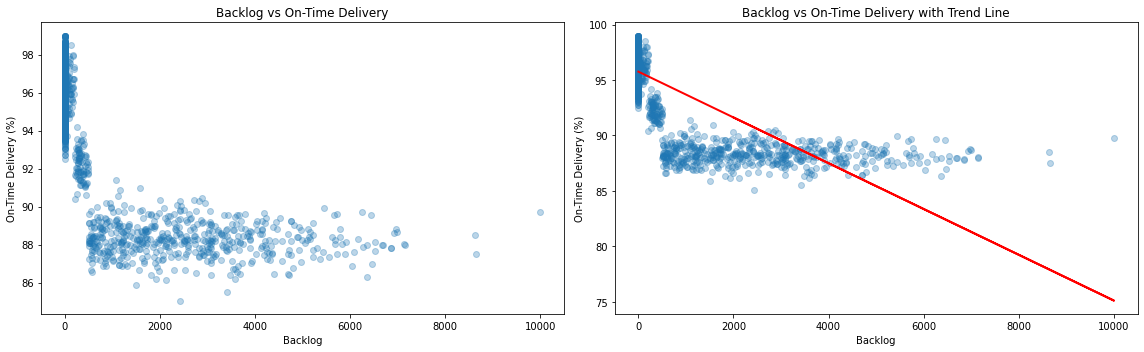

In [69]:
x = df["backlog"]
y = df["on_time_ships_percet"]

# Calculate trend line
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# scatter plot
axes[0].scatter(
    x,
    y,
    alpha=0.3
)

axes[0].set_title("Backlog vs On-Time Delivery")
axes[0].set_xlabel("Backlog")
axes[0].set_ylabel("On-Time Delivery (%)")


# scatter with trend
axes[1].scatter(
    x,
    y,
    alpha=0.3
)

axes[1].plot(
    x,
    trend_line,
    color="red",
    linewidth=2
)

axes[1].set_title("Backlog vs On-Time Delivery with Trend Line")
axes[1].set_xlabel("Backlog")
axes[1].set_ylabel("On-Time Delivery (%)")


plt.tight_layout()
plt.show()


In [70]:
from scipy.stats import linregress
regression = linregress(
df["backlog"],
df["on_time_ships_percet"]
)

print(f"Slope: {regression.slope:.6f}")
print(f"Intercept: {regression.intercept:.2f}")
print(f"R-value: {regression.rvalue:.3f}")
print(f"R-squared: {regression.rvalue ** 2:.3f}")
print(f"P-value: {regression.pvalue:.10f}")

# Regression gives us an approximate relationship: “For every unit increase in backlog, the predicted change in on-time delivery is approximately X.”




Slope: -0.002064
Intercept: 95.75
R-value: -0.764
R-squared: 0.584
P-value: 0.0000000000


In [71]:
#comparing sevice performance across the bands

utilization_band_analysis = (
df
.groupby("utilization_band")
.agg(
records=("utilization_band", "size"),
avg_utilization=("utilization_perct", "mean"),
avg_backlog=("backlog", "mean"),
avg_error_rate=("errors_percet", "mean"),
avg_on_time=("on_time_ships_percet", "mean")
)
)

utilization_band_analysis

,records,avg_utilization,avg_backlog,avg_error_rate,avg_on_time
utilization_band,,,,,
Low,1569,46.443537,0.000000,0.806150,95.991370
Normal,1359,67.885232,0.000000,0.803635,96.034356
High,1020,79.711843,0.000000,0.796794,96.064353
Very High,849,91.447609,0.000000,1.110895,95.994335
Over Capacity,678,118.692817,2074.839233,1.108215,89.593274


<AxesSubplot:title={'center':'On-Time Delivery by Utilization Band'}, xlabel='utilization_band'>

Text(0.5, 0, 'Utilization Band')

Text(0, 0.5, 'Average On-Time Delivery (%)')

<AxesSubplot:title={'center':'Average Backlog by Utilization Band'}, xlabel='utilization_band'>

Text(0.5, 0, 'Utilization Band')

Text(0, 0.5, 'Average Backlog')

<AxesSubplot:title={'center':'Error Rate by Utilization Band'}, xlabel='utilization_band'>

Text(0.5, 0, 'Utilization Band')

Text(0, 0.5, 'Average Error Rate (%)')

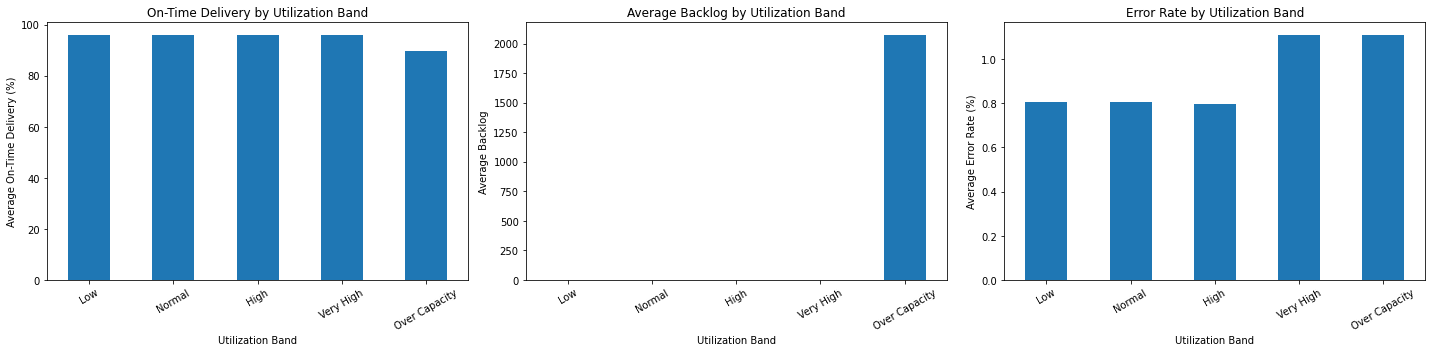

In [72]:
# On time deliv vs util to understand When we’re over capacity, service deteriorates.

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# -------------------------
# 1. On-Time Delivery
# -------------------------
utilization_band_analysis["avg_on_time"].plot(
    kind="bar",
    ax=axes[0],
    title="On-Time Delivery by Utilization Band"
)

axes[0].set_xlabel("Utilization Band")
axes[0].set_ylabel("Average On-Time Delivery (%)")
axes[0].tick_params(axis="x", rotation=30)


# -------------------------
# 2. Average Backlog
# -------------------------
utilization_band_analysis["avg_backlog"].plot(
    kind="bar",
    ax=axes[1],
    title="Average Backlog by Utilization Band"
)

axes[1].set_xlabel("Utilization Band")
axes[1].set_ylabel("Average Backlog")
axes[1].tick_params(axis="x", rotation=30)


# -------------------------
# 3. Error Rate
# -------------------------
utilization_band_analysis["avg_error_rate"].plot(
    kind="bar",
    ax=axes[2],
    title="Error Rate by Utilization Band"
)

axes[2].set_xlabel("Utilization Band")
axes[2].set_ylabel("Average Error Rate (%)")
axes[2].tick_params(axis="x", rotation=30)


plt.tight_layout()
plt.show()


* Higher utilization
↓
* Higher backlog
↓
* Lower on-time delivery
↓
* Higher utilization
↓
* Higher error rate

In [73]:
# Final Summary

final_analysis_summary = pd.DataFrame({
"Finding": [
"Utilization vs Backlog",
"Utilization vs Error Rate",
"Utilization vs On-Time Delivery",
"Backlog vs On-Time Delivery",
"WH03 Backlog Rate",
"WH05 Backlog Rate",
"WH03 High-Pressure Rate",
"WH05 High-Pressure Rate"
],
"Value": [
"r = 0.655, p < 0.001",
"r = 0.530, p < 0.001",
"r = -0.634, p < 0.001",
"r = -0.764, p < 0.001",
"2.93%",
"2.91%",
"17.35%",
"16.62%"
],
"Interpretation": [
"Higher utilization is associated with higher backlog",
"Higher utilization is associated with higher error rate",
"Higher utilization is associated with lower on-time delivery",
"Higher backlog is associated with lower on-time delivery",
"Highest overall warehouse backlog rate",
"Second-highest overall warehouse backlog rate",
"Highest high-pressure frequency",
"Second-highest high-pressure frequency"
]
})
final_analysis_summary

,Finding,Value,Interpretation
0,Utilization vs Backlog,"r = 0.655, p < 0.001",Higher utilization is associated with higher b...
1,Utilization vs Error Rate,"r = 0.530, p < 0.001",Higher utilization is associated with higher e...
2,Utilization vs On-Time Delivery,"r = -0.634, p < 0.001",Higher utilization is associated with lower on...
3,Backlog vs On-Time Delivery,"r = -0.764, p < 0.001",Higher backlog is associated with lower on-tim...
4,WH03 Backlog Rate,2.93%,Highest overall warehouse backlog rate
5,WH05 Backlog Rate,2.91%,Second-highest overall warehouse backlog rate
6,WH03 High-Pressure Rate,17.35%,Highest high-pressure frequency
7,WH05 High-Pressure Rate,16.62%,Second-highest high-pressure frequency


In [74]:
final_analysis_summary.to_csv("/Volumes/DATA/logist/data/processed/final_analysis_summary.csv",index=False)

# Business Questions & Findings

## 1. Which warehouses experience the greatest operational pressure?

WH03 and WH05 show the highest relative backlog pressure.

- WH03 backlog rate: 2.93%
- WH05 backlog rate: 2.91%
- WH03 high-pressure frequency: 17.35%
- WH05 high-pressure frequency: 16.62%

WH02 provides an interesting benchmark because it processes the highest shipment volume while maintaining the lowest backlog rate (0.72%) and lowest high-pressure frequency (6.21%).

**Business implication:** WH03 and WH05 should be investigated for capacity allocation, staffing, workload distribution and process differences.

---

## 2. Does higher utilization correspond to higher backlog?

Pearson correlation between utilization and backlog:

- r = 0.655
- p < 0.001

The analysis shows a statistically significant positive association between utilization and backlog.

**Business implication:** Utilization can be monitored as an early warning indicator for potential backlog accumulation.

---

## 3. Does higher utilization correspond to higher error rates?

Pearson correlation between utilization and error rate:

- r = 0.530
- p < 0.001

Higher utilization is significantly associated with higher error rates in the simulated dataset.

**Business implication:** Quality monitoring becomes particularly important when operational capacity is under pressure.

---

## 4. Does higher utilization correspond to lower on-time delivery?

Pearson correlation between utilization and on-time delivery:

- r = -0.634
- p < 0.001

Higher utilization is associated with lower on-time delivery performance.

**Business implication:** Sustained high utilization may create service-level risk.

---

## 5. Does backlog affect service performance?

Pearson correlation between backlog and on-time delivery:

- r = -0.764
- p < 0.001

Backlog has the strongest negative relationship with on-time delivery among the main operational KPIs examined.

**Business implication:** Reducing backlog should be a key operational priority because backlog accumulation is strongly associated with weaker service performance.

---

## 6. What happens during peak periods?

Peak periods show:

- Average utilization: 103.54%
- Average backlog: 921
- Error rate: 1.11%
- On-time delivery: 93.15%

Normal periods show:

- Average utilization: 62.42%
- Average backlog: 0
- Error rate: 0.80%
- On-time delivery: 96.03%

**Business implication:** Peak periods represent the greatest operational risk and require proactive capacity planning.

---

## 7. Which shift requires further investigation?

S3 has:

- Lowest average productivity: 6.48
- Highest average utilization: 76.37%
- Highest average error rate: 0.90%
- Lowest average on-time delivery: 95.11%

**Business implication:** S3 should be investigated for staffing, workload allocation and process differences.

---

## 8. Which warehouse is most vulnerable during peak periods?

WH03 has the highest peak backlog rate at 6.74%.

WH04 has the weakest peak on-time delivery at 92.75%.

**Business implication:** Different warehouses may require different interventions. WH03 requires attention to backlog/capacity, while WH04 requires particular attention to service performance during peak periods.





# Limitations

This project uses a simulated logistics operations dataset created for portfolio and analytical demonstration purposes. The results should not be interpreted as actual DHL operational performance.

The analysis identifies associations rather than causal relationships. Correlation does not prove that one operational variable causes another.

The dataset does not include several potentially important operational factors, including:

- Staffing levels
- Absence rates
- Package characteristics
- Process layout
- Automation level
- Equipment availability
- Actual service commitments
- Weather or disruption events
- Customer/product mix

Therefore, recommendations should be treated as analytical hypotheses that would require validation with real operational data.


In [75]:
print("/Volumes/DATA/logist/data/processed/cleaned_oper.csv")

/Volumes/DATA/logist/data/processed/cleaned_oper.csv
